<a href="https://colab.research.google.com/github/Yilalu/cnn_satellite_image_classification/blob/main/cnn_satellite_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Convolutional Neural Network (CNN)

# Satellite Image Classification with CNN

## Problem Statement

Satellite imagery is one of the richest sources of information we have
about how land is being used - where crops are growing, where cities are
expanding, where forests are shrinking. But there's far more satellite
imagery being captured than any team of humans could label or review by
hand. Automating land-cover classification makes it possible to track
these changes at scale.

This project builds a Convolutional Neural Network that classifies a
satellite image into one of ten land-cover categories (crops, forest,
pasture, highway, industrial, residential, river, sea/lake, etc.) purely
from the image itself.

**Why this matters**: automated land-cover classification is used for
things like monitoring deforestation, tracking urban sprawl, estimating
crop yields, and supporting disaster response (e.g. spotting flooded
areas). Doing this by hand across large regions isn't practical - a
model that can classify imagery automatically makes large-scale,
frequent monitoring possible.

**Who would use this**: environmental agencies, urban planners,
agricultural analysts, and researchers working with remote-sensing data,
typically as one component in a larger pipeline (e.g. flagging areas of
change for a human to review, rather than fully replacing human judgment).

## Dataset

This project uses the **EuroSAT** dataset, a widely used benchmark for
satellite image classification.

- **Source**: EuroSAT, derived from ESA's Sentinel-2 satellite imagery.
  (https://github.com/phelber/EuroSAT)
- **Size**: ~27,000 labeled RGB images total, split 80% train / 10%
  validation / 10% test.
- **Resolution**: images are natively 64x64 pixels, each covering a
  640m x 640m patch of ground (10 meters per pixel).
- **Classes (10)**: AnnualCrop, Forest, HerbaceousVegetation, Highway,
  Industrial, Pasture, PermanentCrop, Residential, River, SeaLake -
  roughly balanced across classes (~2,000-3,000 images each).

In [1]:
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


2026-07-16 23:06:25.702343: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-16 23:06:25.947027: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-16 23:06:28.884771: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Dataset Preparation

The dataset is split into training, validation, and test sets so that
model performance can be measured on data it never saw during training
or tuning:

- **Training (80%)** – used to fit the model
- **Validation (10%)** – used to monitor training and guide tuning decisions
- **Test (10%)** – held out completely until final evaluation

The split is done in two steps: an initial 80/20 split, then the
remaining 20% is divided evenly into validation and test. This keeps
the test set fully untouched during training and hyperparameter tuning,
so the final accuracy reported later reflects genuine generalization,
not a number the model or its settings were tuned against.

In [2]:
# CONFIGURATION
DATA_DIR= "satellite_data"
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 64
NUM_CLASSES = 10
INPUT_SHAPE = IMAGE_SIZE + (3,)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# load the dataset
all_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)
print("Dataset loaded successfully.")
class_names = all_dataset.class_names
print("Number of classes:", len(class_names))
print("Classes found:", class_names)

# Let's print the number of images in each class
class_counts = {class_name: 0 for class_name in class_names}

for images, labels in all_dataset:
    for label in labels.numpy():
        class_counts[class_names[label]] += 1
print("Number of images in each class:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")


Found 27000 files belonging to 10 classes.


I0000 00:00:1784257595.460716  179198 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Dataset loaded successfully.
Number of classes: 10
Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of images in each class:
AnnualCrop: 3000
Forest: 3000
HerbaceousVegetation: 3000
Highway: 2500
Industrial: 2500
Pasture: 2000
PermanentCrop: 2500
Residential: 3000
River: 2500
SeaLake: 3000


2026-07-16 23:06:37.376999: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [4]:
# 80% of the images are used for training.
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="training",
    color_mode="rgb",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# The remaining 20% is split in half: 10% validation, 10% held-out test set
remainder_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="validation",
    color_mode="rgb",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=None,   # unbatched so split_dataset can divide it cleanly
    shuffle=True
)

valid_ds, test_ds = tf.keras.utils.split_dataset(remainder_ds, left_size=0.5)
valid_ds = valid_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.


2026-07-16 23:06:44.492968: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
# Let's convert our image dataset to a NumPy array for easier manipulation

for images, labels in train_ds.take(1):
    train_images = images.numpy().astype("uint8")
    train_labels = labels.numpy().astype("int32")
for images, labels in valid_ds.take(1):
    valid_images = images.numpy().astype("uint8")
    valid_labels = labels.numpy().astype("int32")

# Now we can check the shapes of our training and validation datasets
print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Validation images shape:", valid_images.shape)
print("Validation labels shape:", valid_labels.shape)


Training images shape: (64, 64, 64, 3)
Training labels shape: (64,)
Validation images shape: (64, 64, 64, 3)
Validation labels shape: (64,)


2026-07-16 23:06:45.877545: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
# Now let's see what the  numbers for the last 20 images in the training dataset are
print("Last 20 training labels:", train_labels[-20:])
print("Last 20 validation labels:", valid_labels[-20:])

Last 20 training labels: [2 7 9 2 1 9 8 3 8 3 4 4 5 0 1 6 4 1 1 9]
Last 20 validation labels: [9 0 7 9 6 1 9 1 8 8 8 6 1 2 7 1 1 0 2 8]


In [7]:
# Let's count the number of images in each class across the FULL training, validation,
# and test sets to confirm the split is balanced (every class should appear in all three).
def count_classes(dataset):
    counts = {class_name: 0 for class_name in class_names}
    for images, labels in dataset:
        for label in labels.numpy():
            counts[class_names[label]] += 1
    return counts

for name, dataset in [("training", train_ds), ("validation", valid_ds), ("test", test_ds)]:
    print("*"*40)
    print(f"Class count in full {name} set")
    print("*"*40)
    for class_name, count in count_classes(dataset).items():
        print(f"{class_name}: {count}")

****************************************
Class count in full training set
****************************************
AnnualCrop: 2403
Forest: 2400
HerbaceousVegetation: 2443
Highway: 2007
Industrial: 1988
Pasture: 1626
PermanentCrop: 2009
Residential: 2393
River: 1953
SeaLake: 2378
****************************************
Class count in full validation set
****************************************
AnnualCrop: 298
Forest: 291
HerbaceousVegetation: 253
Highway: 247
Industrial: 277
Pasture: 200
PermanentCrop: 234
Residential: 326
River: 265
SeaLake: 309
****************************************
Class count in full test set
****************************************
AnnualCrop: 299
Forest: 309
HerbaceousVegetation: 304
Highway: 246
Industrial: 235
Pasture: 174
PermanentCrop: 257
Residential: 281
River: 282
SeaLake: 313


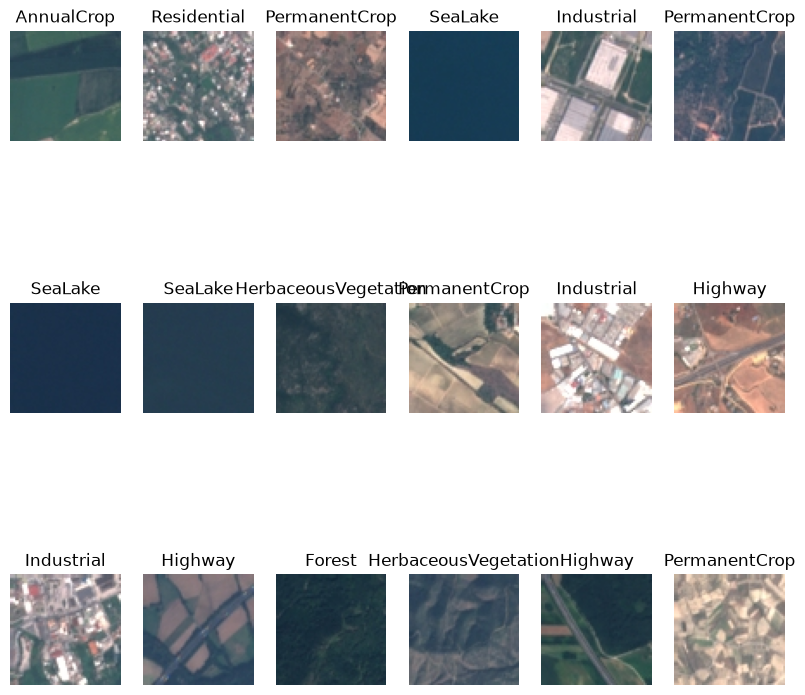

In [8]:
# Let's visualize some of the images in the training dataset along with their labels to ensure that the data is loaded correctly.
plt.figure(figsize=(10, 10))
for i in range(18):
    ax = plt.subplot(3, 6, i + 1)
    plt.imshow(train_images[i].astype("uint8"))
    plt.title(class_names[train_labels[i]])
    plt.axis("off")
plt.show()

### Dataset Preprocessing 

- Data Normalization
- Data Augmentation
- Pipeline Optimization

The pixel values are normalized from the range **0–255** to **0–1** using a rescaling layer. Normalization improves numerical stability during training and helps the model converge more efficiently.


Data augmentation is applied only to the training dataset to increase the diversity of the training images and reduce overfitting. Random transformations such as flipping, rotation, and zooming help the model learn features that are more robust to variations in satellite imagery.

The TensorFlow data pipeline is optimized to improve training performance. The training dataset is shuffled to randomize the order of the images, while caching and prefetching are used to reduce data loading time and improve GPU utilization during training.

In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), # Flip images horizontally with 50% probability
    tf.keras.layers.RandomRotation(0.1),     # Rotate images by up to 10% of a full rotation
    tf.keras.layers.RandomZoom(0.1)          # Zoom into images by up to 10%
])

AUTOTUNE = tf.data.AUTOTUNE # This allows TensorFlow to automatically tune the performance of the data loading pipeline.

train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
) # Prefetch data for optimal performance

val_ds = (
    valid_ds
    .cache()
    .prefetch(AUTOTUNE)
) # Prefetch data for optimal performance

test_ds = (
    test_ds
    .cache()
    .prefetch(AUTOTUNE)
) # Held out for final evaluation only - not touched during training or tuning

### Build the model

A Convolutional Neural Network (CNN) is developed to classify satellite images into 10 different classes. CNNs are effective for image classification because they can automatically learn spatial features such as edges, textures, and patterns from images.

The model consists of multiple convolutional layers followed by max-pooling layers to extract and reduce spatial features. A dropout layer is included to reduce overfitting, and the final dense layer uses a softmax activation function to output the probability distribution across the 10 classes.

The input images have dimensions of 64 × 64 pixels with 3 RGB channels.

In [10]:
image_model = tf.keras.Sequential([
    # Input layer with the shape of the images
    tf.keras.layers.Input(shape=INPUT_SHAPE),  # Input layer with the shape of the images

    # Normalization layer to scale pixel values to [0, 1]
    normalization_layer,   
    # Data augmentation layer to apply random transformations to the images during training
    data_augmentation,

    # First Convolutional layer with 32 filters, a kernel size of 3x3, and ReLU activation
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    # MaxPooling layer to reduce the spatial dimensions of the feature maps
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Second Convolutional layer with 64 filters, a kernel size of 3x3, and ReLU activation
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    # MaxPooling layer to reduce the spatial dimensions of the feature maps
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Third Convolutional layer with 128 filters, a kernel size of 3x3, and ReLU activation
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    # MaxPooling layer to reduce the spatial dimensions of the feature maps
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Flatten layer to convert the 2D feature maps into a 1D feature vector
    tf.keras.layers.Flatten(),

    # Dense layer with 128 units and ReLU activation
    tf.keras.layers.Dense(128, activation='relu'),

    # Output layer with NUM_CLASSES units and softmax activation for multi-class classification
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')

], name="image_model")

# Compile the model with Adam optimizer, sparse categorical crossentropy loss, and accuracy metric
image_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

# Let's print the model summary to see the architecture and number of parameters
image_model.summary()

Model: "image_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,242 (4.36 MB)

 Trainable params: 1,143,242 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Baseline Model

This is the baseline CNN, trained as-is with no hyperparameter tuning or architecture changes. `EarlyStopping` monitors validation loss so training stops once it stops improving, and the best weights are restored automatically. This run sets the reference performance that later tuning passes will be compared against.

The held-out test set (`test_ds`) is not used here, it stays untouched until a final model is selected.

In [11]:
EPOCHS = 30 # Generous upper bound - EarlyStopping will halt training once val_loss stops improving

# Stop training when validation loss stops improving, and roll back to the best weights seen
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the baseline model and keep the history for the curves below
history = image_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/30


/home/gbelew/revature/project/cnn_satellite_image_classification/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-16 23:06:53.871243: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92400


338/338 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.3440 - loss: 1.7549 - val_accuracy: 0.4889 - val_loss: 1.4198
Epoch 2/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5235 - loss: 1.3309 - val_accuracy: 0.5511 - val_loss: 1.2622
Epoch 3/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5697 - loss: 1.1736 - val_accuracy: 0.6263 - val_loss: 1.0831
Epoch 4/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.6156 - loss: 1.0507 - val_accuracy: 0.6130 - val_loss: 1.0618
Epoch 5/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.6430 - loss: 0.9815 - val_accuracy: 0.6533 - val_loss: 1.0267
Epoch 6/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.6707 - loss: 0.9083 - val_accuracy: 0.6667 - val_loss: 0.9373
Epoch 7/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.6902 - loss: 0.8503 - val_accuracy: 0.6589 - val_loss: 0.9955
Epoch 8/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7114 - loss: 0.8027 - val_accuracy: 0.6

#### Baseline Training Curves

In [12]:
#Some helper functions to visualize the training and validation accuracy and loss curves over epochs.

def plot_training_curves(history, title_prefix=""):
    """
    Plots training vs. validation accuracy and loss side by side for one
    model's training history.
    """
    # Pull the per-epoch metrics out of Keras's History object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Left subplot: accuracy curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{title_prefix}Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    # Right subplot: loss curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{title_prefix}Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.tight_layout()
    plt.show()

def evaluate_on_test_set(model, test_ds, class_names, title, show_report=True):
    """
    Runs a full test-set evaluation for a given model:
    1. Overall test accuracy/loss
    2. A confusion matrix (which classes get mixed up with which)
    3. Per-class precision/recall/F1 report (classification_report)

    show_report defaults to True. Set it to False if you only need the
    accuracy/loss and confusion matrix for a quick comparison run.
    """
    # Overall accuracy/loss on the held-out test set
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Test Loss:     {test_loss:.4f}")

    # Collect predictions across every batch in the test set so we can
    # build the confusion matrix and classification report below
    y_true, y_pred = [], []
    for images, labels in test_ds:
        probs = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(probs, axis=1))  # predicted class = highest-probability class
        y_true.extend(labels.numpy())
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Confusion matrix - shows which land-cover classes get confused with each other
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
    plt.title(f'Confusion Matrix - {title}')
    plt.tight_layout()
    plt.show()

    # Per-class precision/recall/F1 - reveals weak classes a single accuracy number would hide
    if show_report:
        print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

    return test_accuracy, test_loss, y_true, y_pred


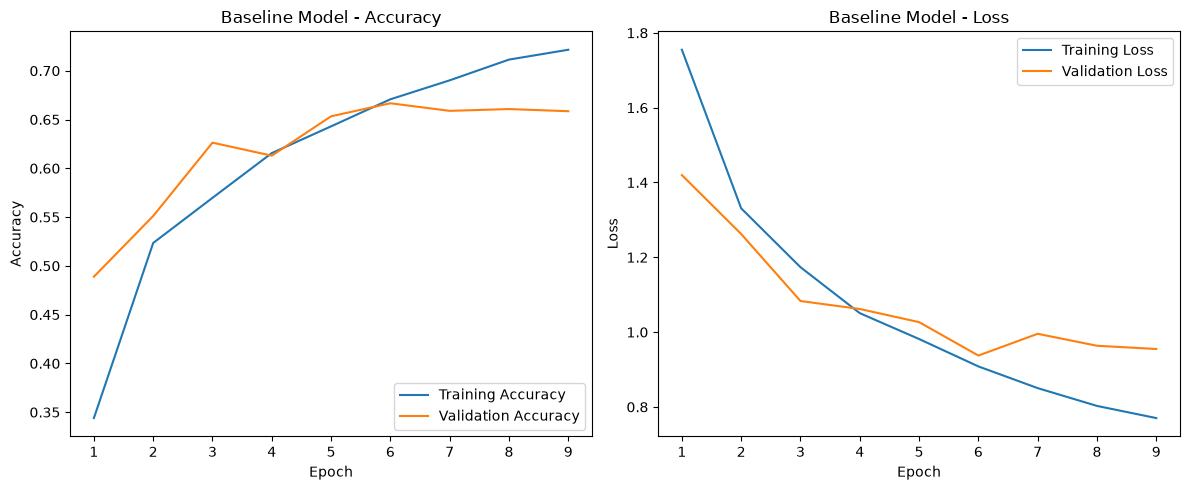

In [13]:
# Plot training vs. validation accuracy/loss curves for the baseline model
plot_training_curves(history, title_prefix="Baseline Model - ")

Test Accuracy: 0.6507
Test Loss:     0.9967


2026-07-16 23:08:21.139186: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


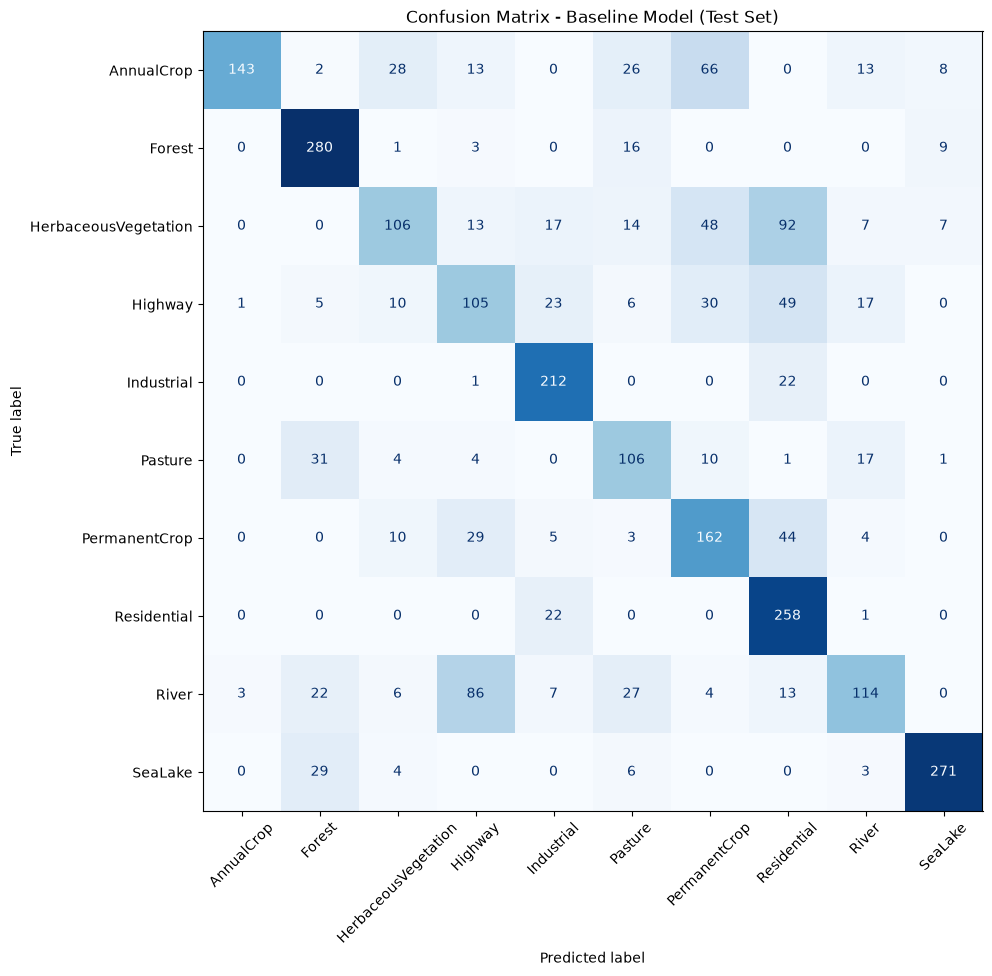

                      precision    recall  f1-score   support

          AnnualCrop      0.973     0.478     0.641       299
              Forest      0.759     0.906     0.826       309
HerbaceousVegetation      0.627     0.349     0.448       304
             Highway      0.413     0.427     0.420       246
          Industrial      0.741     0.902     0.814       235
             Pasture      0.520     0.609     0.561       174
       PermanentCrop      0.506     0.630     0.562       257
         Residential      0.539     0.918     0.679       281
               River      0.648     0.404     0.498       282
             SeaLake      0.916     0.866     0.890       313

            accuracy                          0.651      2700
           macro avg      0.664     0.649     0.634      2700
        weighted avg      0.679     0.651     0.641      2700

Baseline Model Accuracy: 0.6507407426834106, Loss: 0.9966605305671692


In [14]:
# Build the confusion matrix to see which classes get mixed up with each other
baseline_accuracy, baseline_loss, baseline_y_true, baseline_y_pred = evaluate_on_test_set(
    image_model, test_ds, class_names, title="Baseline Model (Test Set)", show_report=True
)
print(f"Baseline Model Accuracy: {baseline_accuracy}, Loss: {baseline_loss}")

### Improved Model: Fixing the Baseline's Problems
The baseline model had two core problems: **unstable training** (validation accuracy stalled and 
stayed inconsistent across epochs) and an **inefficient
architecture** (a single Flatten - Dense layer held millions of parameters,
making it prone to overfitting and slow to train). We updated some parameters here:

- **BatchNormalization after each convolution** – the baseline had none,
  which is a likely cause of its unstable training. BatchNorm keeps
  activations well-scaled as they pass through the network, smoothing out
  training.
- **GlobalAveragePooling2D instead of Flatten** – the baseline's
  Flatten - Dense connection held over 4 million parameters in a single
  layer, most of the model's total weight. Replacing it cuts those
  parameters dramatically, directly reducing the model's tendency to
  overfit.
- **Higher learning rate (1e-3) with ReduceLROnPlateau** – the baseline
  used a small, fixed learning rate (1e-4) with no scheduler. BatchNorm
  makes a larger learning rate stable, and the scheduler automatically
  lowers it once validation loss plateaus, instead of training at one
  fixed rate throughout.
- **Extra conv block (256 filters) added at the smallest spatial
  resolution, with pooling depth kept the same as the baseline** – gives
  the network more capacity to learn abstract features, without further
  shrinking the spatial detail available to the final classification
  layers.
- **Dropout (0.5) and stronger augmentation (added RandomContrast)** – the
  baseline had no dropout and lighter augmentation. With more model
  capacity from the extra conv block, stronger regularization was needed
  to keep the model from memorizing the training set instead of
  generalizing.

**Result**: the baseline model's test accuracy and per-class performance
served as the reference point throughout - each change above was validated
by confirming it moved test accuracy in the right direction.
We arrived at these settings through repeated trial and error, running 
the model, checking the accuracy, and adjusting from there.

In [15]:
data_augmentation_v2  = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), # Flip images horizontally with 50% probability
    tf.keras.layers.RandomRotation(0.1),     # Rotate images by up to 10% of a full rotation
    tf.keras.layers.RandomZoom(0.1),         # Zoom into images by up to 10%
    tf.keras.layers.RandomContrast(0.1)      # Randomly adjust the contrast of the images by up to 10%
])

In [16]:
image_model_v2 = tf.keras.Sequential([
    # Input layer with the shape of the images
    tf.keras.layers.Input(shape=INPUT_SHAPE),  # Input layer with the shape of the images

    # Normalization layer to scale pixel values to [0, 1]
    normalization_layer,
    # Data augmentation layer to apply random transformations to the images during training
    data_augmentation_v2,

    # First Convolutional block: Conv -> BatchNorm -> MaxPooling
    # BatchNormalization stabilizes training
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Second Convolutional block
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Third Convolutional block
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Fourth Convolutional block
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),

    # GlobalAveragePooling replaces Flatten: it collapses each feature map to a single
    # value, cutting millions of dense-layer parameters and reducing overfitting
    tf.keras.layers.GlobalAveragePooling2D(),

    # Dense layer with 256 units and ReLU activation
    tf.keras.layers.Dense(256, activation='relu'),
    # Dropout layer to further reduce overfitting
    tf.keras.layers.Dropout(0.5),

    # Output layer with NUM_CLASSES units and softmax activation for multi-class classification
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')

], name="image_model_v2")

# Compile with a higher learning rate (1e-3) - BatchNorm makes this stable, and
# ReduceLROnPlateau will lower it automatically when needed
image_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

# Print the model summary to see the architecture and number of parameters
image_model_v2.summary()

Model: "image_model_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,698 (1.75 MB)

 Trainable params: 457,738 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

In [17]:
EPOCHS = 30

# Stop training when validation loss stops improving, and roll back to the best weights seen
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

# Drop the learning rate when val_loss plateaus so the model can keep refining
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5, # Halve the learning rate each time it triggers
    patience=3, # Wait 3 epochs with no improvement before reducing
    min_lr=1e-6
)

# Train the improved model and keep the history for the curves below
history_v2 = image_model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/30


/home/gbelew/revature/project/cnn_satellite_image_classification/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


338/338 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.6867 - loss: 0.8921 - val_accuracy: 0.2493 - val_loss: 4.4760 - learning_rate: 0.0010
Epoch 2/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 32s 95ms/step - accuracy: 0.7803 - loss: 0.6306 - val_accuracy: 0.5763 - val_loss: 1.5129 - learning_rate: 0.0010
Epoch 3/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 33s 98ms/step - accuracy: 0.8207 - loss: 0.5182 - val_accuracy: 0.7511 - val_loss: 0.7990 - learning_rate: 0.0010
Epoch 4/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 40s 119ms/step - accuracy: 0.8531 - loss: 0.4254 - val_accuracy: 0.7744 - val_loss: 0.6315 - learning_rate: 0.0010
Epoch 5/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - accuracy: 0.8751 - loss: 0.3615 - val_accuracy: 0.8144 - val_loss: 0.5698 - learning_rate: 0.0010
Epoch 6/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.8936 - loss: 0.3182 - val_accuracy: 0.8726 - val_loss: 0.3878 - learning_rate: 0.0010
Epoch 7/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.9022 - loss: 0.287

#### Improved Model Training Curves

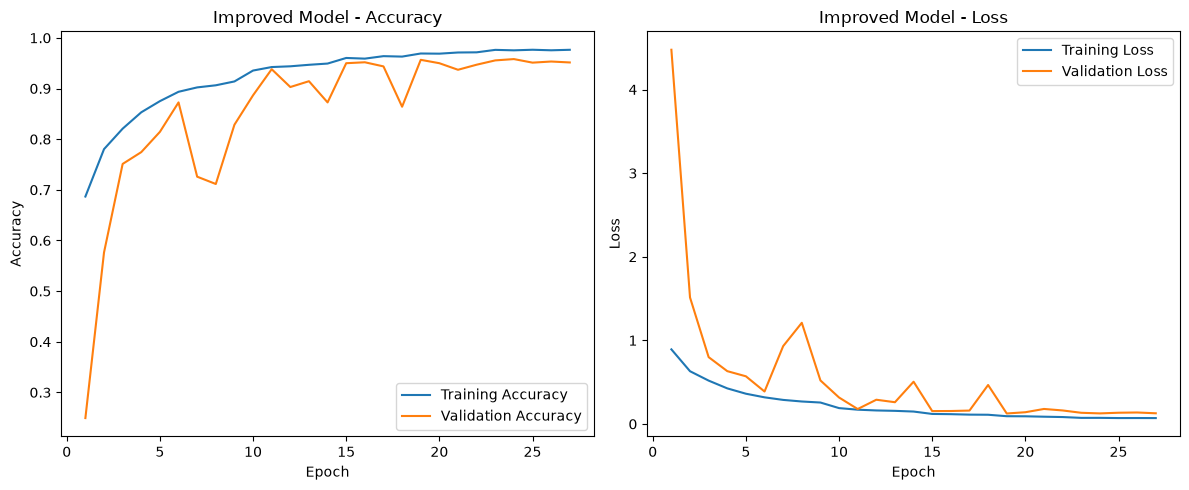

In [18]:
# Plot training vs. validation accuracy/loss curves for the improved model
plot_training_curves(history_v2, title_prefix="Improved Model - ")

### Final Evaluation on the Held-Out Test Set

With the improved model training well, we now evaluate it once on the test set. This gives an unbiased estimate of real-world performance.

We look at three things:

- **Test accuracy and loss** - overall performance on unseen data.
- **Confusion matrix** – which land-cover classes get confused with each other
- **Classification report** – per-class precision, recall, and F1-score, which reveal weak classes that a single accuracy number would hide.

Test Accuracy: 0.9515
Test Loss:     0.1437


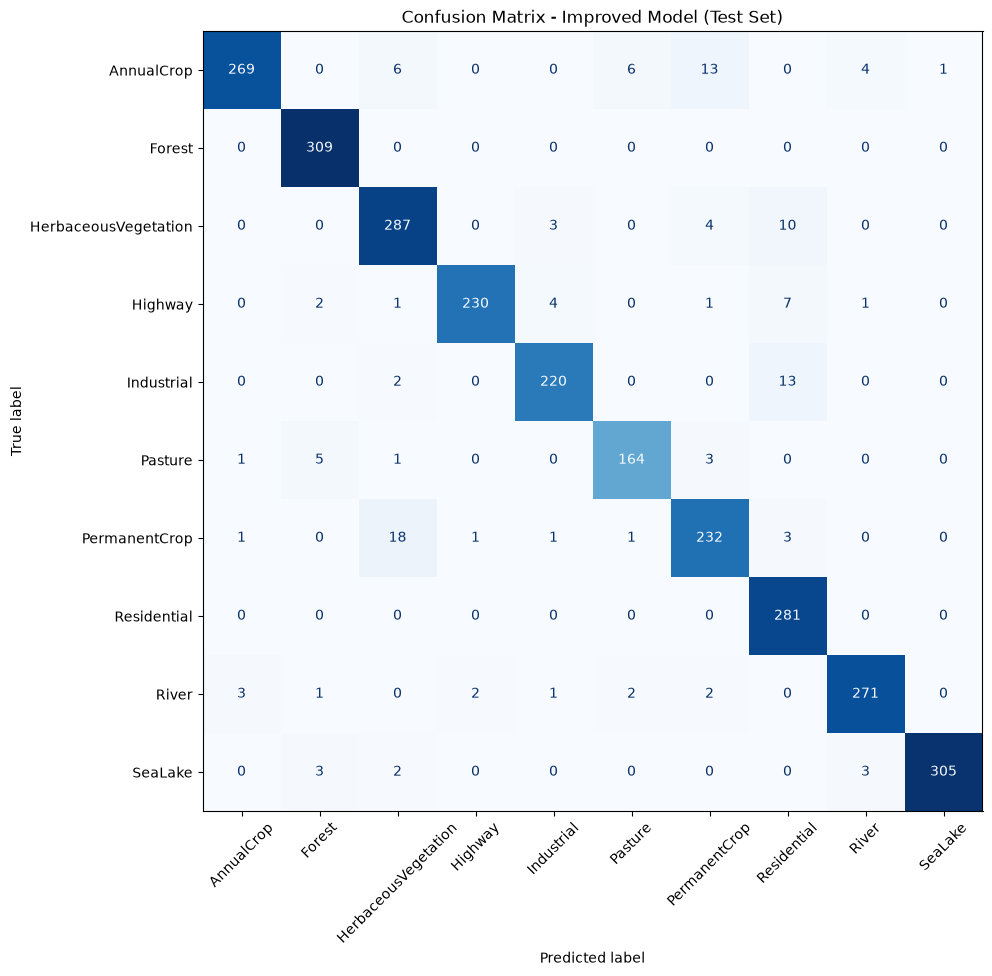

                      precision    recall  f1-score   support

          AnnualCrop      0.982     0.900     0.939       299
              Forest      0.966     1.000     0.983       309
HerbaceousVegetation      0.905     0.944     0.924       304
             Highway      0.987     0.935     0.960       246
          Industrial      0.961     0.936     0.948       235
             Pasture      0.948     0.943     0.945       174
       PermanentCrop      0.910     0.903     0.906       257
         Residential      0.895     1.000     0.945       281
               River      0.971     0.961     0.966       282
             SeaLake      0.997     0.974     0.985       313

            accuracy                          0.951      2700
           macro avg      0.952     0.950     0.950      2700
        weighted avg      0.953     0.951     0.951      2700

Improved Model Accuracy: 0.9514814615249634, Loss: 0.14373444020748138


In [19]:
# Full evaluation for the improved model: accuracy/loss, confusion matrix, and classification report.
v2_accuracy, v2_loss, y_true, y_pred = evaluate_on_test_set(
    image_model_v2, test_ds, class_names, title="Improved Model (Test Set)", show_report=True
)
print(f"Improved Model Accuracy: {v2_accuracy}, Loss: {v2_loss}")

### Misclassified Examples

Accuracy and the confusion matrix show *how often* the model gets things
wrong and *which* classes it confuses, but not *what those mistakes
actually look like*. This section pulls a sample of misclassified test
images and displays them with their true and predicted labels, to check
whether the errors are reasonable (visually similar classes) or actual
model weaknesses.

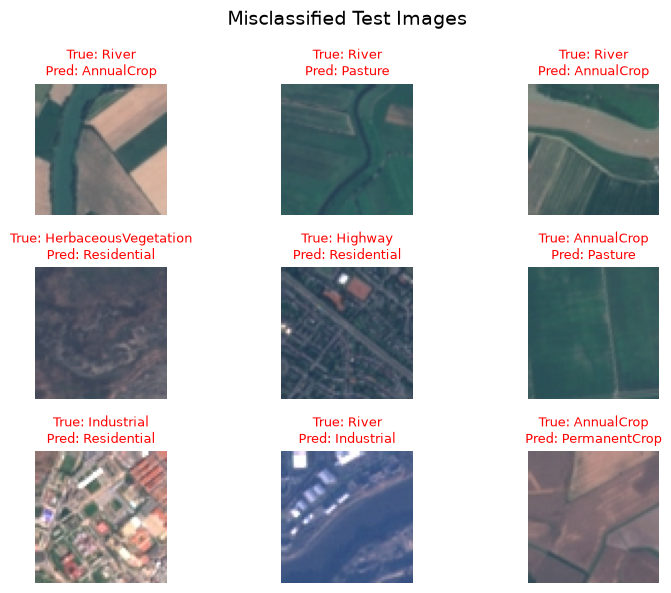

In [20]:

# Find indices where the predicted label doesn't match the true label
misclassified_idx = np.where(y_true != y_pred)[0]
# print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_true)} test images")

# Re-collect the actual image tensors from test_ds so we can display them
# (y_true/y_pred only stored labels, not the images themselves)
all_test_images = []
for images, labels in test_ds:
    all_test_images.extend(images.numpy())
all_test_images = np.array(all_test_images)

# Show a grid of some misclassified examples with true vs. predicted labels
num_to_show = min(9, len(misclassified_idx))
sample_idx = np.random.choice(misclassified_idx, size=num_to_show, replace=False)

plt.figure(figsize=(8, 6))
for plot_i, idx in enumerate(sample_idx):
    ax = plt.subplot(3, 3, plot_i + 1)
    plt.imshow(all_test_images[idx].astype("uint8"))
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9, color="red")
    plt.axis("off")

plt.suptitle("Misclassified Test Images", fontsize=14)
plt.tight_layout()
plt.show()

### Saving The Model

In [21]:
# Now let's save the model to disk so we can load it later without retraining
model_save_path = "saved_models/image_model_v2.keras"
image_model_v2.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to saved_models/image_model_v2.keras


## Limitations and Next Steps

### What the model does well

The final model reaches 95.9% accuracy on the held-out test set, with most
classes scoring an F1 above 0.94. Visually and structurally distinct classes
like Forest, SeaLake, and River are classified very reliably (F1 ≈ 0.98),
which makes sense - these have clear color and texture signatures that don't
overlap much with other classes.

### What it struggles with

The weakest classes are AnnualCrop, PermanentCrop, Highway, Residential and HerbaceousVegetation
(F1 in the 0.92-0.94 range), and the misclassified examples confirm why:
these classes look visually similar even on inspection - different crop
types photographed from directly overhead can share very similar colors,
row patterns, and textures. This isn't a case of the model being obviously
wrong; it's a genuinely hard visual distinction, and some of the confusion
would likely trip up a person looking at the same small image without
additional context (season, exact crop type, etc).

### Dataset limitations

This is the more significant limitation, and one we found through direct
testing rather than assuming it upfront: **the model does not generalize
to satellite/aerial images from other sources.** Images pulled from the
open internet or other imagery sources performed very poorly, even for
scenes that look like "obvious" categories.

Two compounding reasons for this, both tied to how the training data was
built:

- **Narrow source distribution** - EuroSAT images all come from one
  satellite sensor (Sentinel-2), captured at a fixed altitude/resolution
  (10m/pixel) and processed the same way. The model learned to recognize
  *that specific imaging style*, not the general concept of "forest" or
  "river" as it might appear from any camera, angle, or sensor.
- **Native resolution is only 64x64** - even the training images
  themselves are lower-resolution than they may appear. Any real-world
  image with genuinely sharp detail looks statistically different to the
  model than anything it was trained on, on top of the sensor/color
  mismatch above.

So while the model performs strongly *within* the EuroSAT distribution,
that 95.9% number shouldn't be read as "this model can classify any
satellite image" - it's a much narrower, sensor-specific result.

### What we'd do with more time or data

- **Test against a genuinely different benchmark** (e.g. NWPU-RESISC45,
  which shares several overlapping classes but comes from a different
  sensor and resolution range) to get a real, quantified measure of
  cross-domain generalization, instead of relying on anecdotal internet
  images.
- **Train on a combination of sources**, not just EuroSAT alone, so the
  model sees multiple sensors, resolutions, and color-processing styles
  during training rather than just one.
- **Try transfer learning** from a model pretrained on broader aerial/
  remote-sensing imagery, rather than training a CNN from scratch on a
  single narrow dataset.
- **Add stronger/more varied augmentation** aimed specifically at
  simulating sensor differences (color jitter, blur/sharpness variation),
  not just geometric changes like flips and rotation, since that's the
  actual axis the model is currently weak on.